# Predicción de puntaje Saber 11 (Pipeline final)

**Aprendizaje de Máquina Aplicado** · Universidad EAFIT · 2026

**Equipo:** Patricia Arango, Santiago Higuita, Alexander Pelaez  
**Repositorio:** [ml_project_eafit](https://github.com/AlexanderPelaezJimenez/ml_project_eafit)

Este notebook es el **entregable final** del proyecto. Cierra el ciclo que arrancó con la entrega 1 (problema, datos, EDA y baseline) y muestra cómo, partiendo de las brechas socioeconómicas que vimos en el EDA, construimos un pipeline de regresión que predice `punt_global` y un champion serializado, listo para ser servido en una app.

## Contenido

1. [Resumen ejecutivo](#1-resumen-ejecutivo)
2. [Contexto y objetivos](#2-contexto-y-objetivos)
3. [Datos](#3-datos)
4. [Metodología](#4-metodología)
5. [Configuración global](#5-configuración-global)
6. [Carga del dataset y split](#6-carga-del-dataset-y-split)
7. [Pipeline de modelado](#7-pipeline-de-modelado)
8. [Tuning y selección del champion](#8-tuning-y-selección-del-champion)
9. [Evaluación en test holdout](#9-evaluación-en-test-holdout)
10. [Validaciones de robustez](#10-validaciones-de-robustez)
11. [Diagnósticos: residuales y fairness](#11-diagnósticos-residuales-y-fairness)
12. [Interpretabilidad con SHAP](#12-interpretabilidad-con-shap)
13. [Persistencia del champion](#13-persistencia-del-champion)
14. [Conclusiones](#14-conclusiones)

## 1. Resumen ejecutivo

**Champion:** XGBoost (40 trials con Optuna, 3-fold CV).

**Métricas en test holdout (679,167 registros):**

| Métrica | Valor |
|---|---|
| RMSE | 36.60 |
| MAE | 29.14 |
| R² | 0.460 |

El modelo explica el **46% de la varianza** del puntaje global usando solo variables socioeconómicas y características del colegio. La diferencia entre RMSE de CV (36.71) y holdout (36.60) confirma que no hay overfitting. 

**Top 5 features (SHAP):**
- educación máxima de los padres
- edad del estudiante
- % de internet en el municipio
- género
- jornada del colegio. 

Confirman las brechas identificadas en el EDA de la entrega 1.

**Robustez:** la métrica se degrada de 36.6 (holdout) a 40.1 (GroupKFold por municipio) y 40.4 (split temporal sobre 2020-2022) cuando cambiamos la distribución sobre la que evaluamos. El modelo generaliza bien dentro de su distribución (CV 36.71 ≈ holdout 36.60), y muestra una degradación baja-moderada (~10%) frente a municipios o cohortes fuera del entrenamiento.

## 2. Contexto y objetivos

El examen Saber 11 (ICFES) es la prueba estandarizada que cierra la educación media en Colombia y condiciona el acceso a la universidad. En la entrega 1 confirmamos lo que la literatura ya sugería: hay brechas grandes y consistentes por estrato, educación de los padres, acceso a tecnología y tipo de colegio.

**Pregunta:** ¿qué tanto del puntaje global puede explicarse con variables socioeconómicas y del entorno educativo, sin usar puntajes parciales?

**Tarea:** regresión supervisada sobre `punt_global` (rango 0–500).

**Métrica primaria:** RMSE. Penaliza errores grandes, que en este dominio son los más costosos: un puntaje muy mal estimado afecta decisiones de admisión y de política. Reportamos también MAE y R² para facilitar la lectura.

**Uso previsto:** herramienta académica para investigación y análisis educativo.

## 3. Datos

Resultados Saber 11 del Portal de Datos Abiertos del Gobierno de Colombia. Después de la limpieza documentada en `03-data-cleaning.ipynb` trabajamos sobre `data/processed/cleaned_dataset.parquet`: 3.4M filas y 28 columnas, periodos 2014-2 a 2022-4.

Detalles (dominios, dtypes, decisiones de limpieza, sesgos conocidos): ver `docs/datacard.md`.

## 4. Metodología

### 4.1 Estrategia de validación y prevención de leakage

Tres líneas de defensa contra leakage:

1. **Eliminación de fuentes de leakage en cleaning.** En `03-data-cleaning` removimos los 5 puntajes parciales (`punt_matematicas`, `punt_lectura_critica`, etc.) y `desemp_ingles`. La correlación con `punt_global` era ≈0.99: incluirlos hubiera dado un R² sesgado sin aprender nada útil.

2. **Pipeline encapsulado.** Imputers, encoders y agregados van dentro de un `sklearn.Pipeline` que se reentrena por fold del CV únicamente con datos de train. Test holdout solo se transforma con el pipeline ya ajustado, nunca con `fit`.

3. **Group aggregates con leave-one-out.** El `GroupAggregatesTransformer` calcula `pct_internet_mcpio` y similares en `fit`. En `fit_transform` (fold de train) usamos LOO para que cada fila reciba el agregado calculado **sin su propia contribución**, eliminando el in-sample bias.

**Split principal:** estratificado por `periodo` (80/20). Es la pregunta razonable de negocio: ¿predigo bien dentro del rango de cohortes vistas? Como ese split deja municipios y colegios en train y test, complementamos con dos validaciones de robustez (sección 10):

- **`GroupKFold` por municipio**: ¿qué pasa con municipios no vistos?
- **Split temporal** (train ≤2019, test ≥2020): ¿qué pasa con cohortes futuras?

### 4.2 Modelos

Tres gradient boosting trees: **LightGBM, XGBoost y CatBoost**. Son robustos a multicolinealidad (relevante porque las features socioeconómicas están correlacionadas), manejan missing values nativamente y suelen ser el estado del arte en datos tabulares heterogéneos.

### 4.3 Tuning

Optuna con TPE (multivariado) + median pruner. Cada trial entrena el pipeline completo sobre los folds de CV; el pruner descarta trials malos temprano. Hiperparámetros buscados en `src/modeling/pipeline.py:PipelineML.build_model_grid`.

## 5. Configuración global

Toda la parametrización del experimento en una sola celda. Cambiarlos aquí afecta toda la ejecución del notebook.

In [ ]:
# Configuración del experimento
SEED = 42
TEST_SIZE = 0.2
N_TRIALS = 40                       # trials de Optuna por modelo
CV_FOLDS = 3                        # folds del CV de tuning
USE_GPU = False                     # cambiar a True en máquina con GPU
MODELS_TO_TUNE = [
    'lightGBM',
    'xgboost',
    'catboost'
]

SHAP_SAMPLE_SIZE = 20_000           # muestra para SHAP
ROBUSTNESS_GROUP_FOLDS = 5          # folds del GroupKFold por municipio
ROBUSTNESS_TRAIN_UNTIL = '20194'    # split temporal: train hasta 2019-4

# Paths
from pathlib import Path

DATA_DIR = Path('../data/processed')
MODELS_DIR = Path('../models')
FIGURES_DIR = Path('../reports/figures')
CHAMPION_DIR = MODELS_DIR / 'champion'

for d in (MODELS_DIR, FIGURES_DIR, CHAMPION_DIR):
    d.mkdir(parents=True, exist_ok=True)

### Imports

In [2]:
import os
import sys

sys.path.append(os.path.dirname(os.getcwd()))

In [3]:
import warnings

import numpy as np
import pandas as pd
import polars as pl
from loguru import logger
from sklearn.model_selection import train_test_split

# Pipeline y utilidades del proyecto
from src.modeling.constants import (
    CLIP_EDAD,
    MAPEO_CUARTOS,
    MAPEO_PERSONAS,
)
from src.modeling.pipeline import PipelineML
from src.modeling.preprocessor import build_preprocessor
from src.modeling.diagnostics import (
    calibration_by_bucket,
    fairness_report,
    plot_predicted_vs_true,
    plot_residual_distribution,
    plot_residual_vs_pred,
    residual_summary,
)
from src.modeling.validation import group_kfold_cv, temporal_holdout
from src.modeling.champion import save_champion

warnings.filterwarnings('ignore', message='X does not have valid feature names')

from optuna.exceptions import ExperimentalWarning
warnings.filterwarnings('ignore', category=ExperimentalWarning)

## 6. Carga del dataset y split

Cargamos el parquet limpio y aplicamos el split estratificado por periodo. El target sale como string del cleaning, lo casteamos a `Int32`.

In [4]:
cleaned_dataset = pl.scan_parquet(DATA_DIR / 'cleaned_dataset.parquet').collect()
logger.info(f'Dimensiones del dataset: {cleaned_dataset.shape}')
cleaned_dataset.head(5)

2026-05-24 11:23:51.369 | INFO     | __main__:<module>:2 - Dimensiones del dataset: (3395834, 28)


cole_sede_principal,cole_caracter,fami_cuartoshogar,fami_educacionpadre,estu_tipodocumento,estu_fechanacimiento,fami_tienecomputador,estu_genero,fami_tienelavadora,fami_personashogar,estu_depto_presentacion,estu_depto_reside,cole_naturaleza,cole_calendario,estu_mcpio_reside,periodo,cole_genero,fami_estratovivienda,cole_area_ubicacion,cole_bilingue,cole_mcpio_ubicacion,estu_mcpio_presentacion,fami_educacionmadre,fami_tieneautomovil,cole_jornada,punt_global,fami_tieneinternet,cole_depto_ubicacion
str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
"""N""","""TÉCNICO/ACADÉMICO""","""Dos""","""Primaria completa""","""TI""","""15/02/2003""","""Si""","""F""","""Si""","""1 a 2""","""HUILA""","""HUILA""","""OFICIAL""","""A""","""AIPE""","""20194""","""MIXTO""","""Estrato 2""","""RURAL""","""N""","""AIPE""","""AIPE""","""Postgrado""","""No""","""COMPLETA""","""339""","""Si""","""HUILA"""
"""S""","""TÉCNICO/ACADÉMICO""","""Dos""","""Primaria incompleta""","""TI""","""08/03/2002""","""No""","""F""","""No""","""5 a 6""","""HUILA""","""HUILA""","""OFICIAL""","""A""","""LA PLATA""","""20194""","""MIXTO""","""Estrato 1""","""URBANO""","""N""","""LA PLATA""","""LA PLATA""","""Primaria incompleta""","""No""","""COMPLETA""","""199""","""No""","""HUILA"""
"""S""","""TÉCNICO/ACADÉMICO""","""Cuatro""","""Secundaria (Bachillerato) comp…","""TI""","""27/07/2000""","""Si""","""M""","""Si""","""Cinco""","""VALLE""","""VALLE""","""OFICIAL""","""A""","""CALI""","""20162""","""MIXTO""","""Estrato 5""","""URBANO""","""N""","""CALI""","""CALI""","""Secundaria (Bachillerato) inco…","""Si""","""MAÑANA""","""272""","""Si""","""VALLE"""
"""S""","""TÉCNICO/ACADÉMICO""","""Cinco""","""Primaria incompleta""","""TI""","""07/12/1999""","""No""","""F""","""Si""","""5 a 6""","""ANTIOQUIA""","""ANTIOQUIA""","""NO OFICIAL""","""A""","""MEDELLÍN""","""20172""","""MIXTO""","""Estrato 2""","""URBANO""","""N""","""MEDELLIN""","""ITAGÜÍ""","""Secundaria (Bachillerato) inco…","""No""","""SABATINA""","""253""","""Si""","""ANTIOQUIA"""
"""S""","""TÉCNICO/ACADÉMICO""","""Dos""","""Primaria incompleta""","""CC""","""15/09/1995""","""No""","""M""","""No""","""Cuatro""","""TOLIMA""","""TOLIMA""","""OFICIAL""","""A""","""SAN LUIS""","""20142""","""MIXTO""","""Estrato 1""","""RURAL""","""N""","""SAN LUIS""","""GUAMO""","""Primaria incompleta""","""No""","""MAÑANA""","""212""","""No""","""TOLIMA"""


In [5]:
X = cleaned_dataset.drop('punt_global')
y = cleaned_dataset['punt_global']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=cleaned_dataset['periodo'],
)

# Conversión a pandas/numpy: el pipeline de sklearn trabaja con pandas.
X_train_pd = X_train.to_pandas()
X_test_pd = X_test.to_pandas()
y_train_np = y_train.cast(pl.Int32).to_numpy().astype(np.float32)
y_test_np = y_test.cast(pl.Int32).to_numpy().astype(np.float32)

logger.info(f'Train: {X_train_pd.shape[0]:,} filas | Test: {X_test_pd.shape[0]:,} filas')
logger.info(f'Proporción test: {X_test_pd.shape[0] / cleaned_dataset.shape[0] * 100:.1f}%')

2026-05-24 11:23:56.467 | INFO     | __main__:<module>:18 - Train: 2,716,667 filas | Test: 679,167 filas
2026-05-24 11:23:56.467 | INFO     | __main__:<module>:19 - Proporción test: 20.0%


## 7. Pipeline de modelado

El pipeline tiene cuatro pasos, en este orden, y se reentrena entero en cada fold:

1. **`DeterministicFeatureProcessor`**: feature engineering puramente determinista (capital tecnológico, hacinamiento, brechas educativas, índice socioeconómico, edad aproximada). Stateless: no aprende nada ni genera estadísticas.

2. **`GroupAggregatesTransformer`**: agregados por municipio y departamento, con leave-one-out en train para evitar in-sample bias. Aquí no usamos el target.

3. **`ColumnTransformer`**: imputación + encoding (ordinal con orden explícito para estrato y educación; OHE para nominales de baja cardinalidad).

4. **Modelo**: LightGBM, XGBoost o CatBoost.

Los transformers viven en `src/modeling/transformers.py` y están cubiertos por tests unitarios en `tests/test_transformers.py`.

In [6]:
preprocessor = build_preprocessor()

full_pipeline_ml = PipelineML(
    preprocessor=preprocessor,
    mapeo_personas=MAPEO_PERSONAS,
    mapeo_cuartos=MAPEO_CUARTOS,
    clip_edad=CLIP_EDAD,
    n_trials_tree=N_TRIALS,
    cv_folds=CV_FOLDS,
    parallel_trials=8,
    cores_per_model=8,
    use_gpu=USE_GPU,
    random_seed=SEED,
)

2026-05-24 11:23:56.472 | INFO     | src.modeling.pipeline:__init__:98 - Maquina detectada: 64 cores. Modo: CPU. parallel_trials=8, cores_per_model=8, concurrencia total=64


## 8. Tuning y selección del champion

Optuna optimiza RMSE de CV para cada uno de los tres modelos. La elección del champion la hacemos manualmente sobre la tabla comparativa: si dos modelos están empatados en RMSE, elegiremos el más simple (menos depth, menos n_estimators) por mantenibilidad.

In [7]:
studies = full_pipeline_ml.tune(X_train_pd, y_train_np, models=MODELS_TO_TUNE)
comparison = full_pipeline_ml.comparison_table()

comparison

2026-05-24 11:24:08.012 | INFO     | src.modeling.pipeline:tune:301 - Ejecutando modelo lightGBM...
[I 2026-05-24 11:24:08,013] A new study created in memory with name: Experimento usando: lightGBM


  0%|          | 0/40 [00:00<?, ?it/s]

[I 2026-05-24 11:33:46,246] Trial 2 finished with value: 37.975422386656845 and parameters: {'n_estimators': 461, 'max_depth': 8, 'learning_rate': 0.02324756798567284, 'num_leaves': 20, 'min_child_samples': 58, 'subsample': 0.998692209844263, 'colsample_bytree': 0.7101246408584511, 'reg_alpha': 6.369196370735157, 'reg_lambda': 6.732831491728408e-08}. Best is trial 2 with value: 37.975422386656845.
[I 2026-05-24 11:34:35,958] Trial 0 finished with value: 37.48332918386925 and parameters: {'n_estimators': 286, 'max_depth': 9, 'learning_rate': 0.02842525931457888, 'num_leaves': 143, 'min_child_samples': 11, 'subsample': 0.69655030856349, 'colsample_bytree': 0.9068586471850139, 'reg_alpha': 2.8289306633469463e-08, 'reg_lambda': 4.181819846914966}. Best is trial 0 with value: 37.48332918386925.
[I 2026-05-24 11:34:48,447] Trial 4 finished with value: 38.28227778993503 and parameters: {'n_estimators': 303, 'max_depth': 10, 'learning_rate': 0.011388217964972578, 'num_leaves': 91, 'min_child_s

2026-05-24 12:18:52.874 | INFO     | src.modeling.pipeline:tune:324 - lightGBM | Mejor RMSE CV: 36.8100
2026-05-24 12:18:52.875 | INFO     | src.modeling.pipeline:tune:325 - lightGBM | Mejores params: {'n_estimators': 701, 'max_depth': 8, 'learning_rate': 0.1199944176396698, 'num_leaves': 130, 'min_child_samples': 71, 'subsample': 0.9136957952425988, 'colsample_bytree': 0.8188255326824175, 'reg_alpha': 0.002377644720322986, 'reg_lambda': 6.328655983560154e-06}
2026-05-24 12:18:52.875 | INFO     | src.modeling.pipeline:tune:301 - Ejecutando modelo xgboost...
[I 2026-05-24 12:18:52,876] A new study created in memory with name: Experimento usando: xgboost


[I 2026-05-24 12:18:52,873] Trial 39 finished with value: 36.83808892993541 and parameters: {'n_estimators': 861, 'max_depth': 8, 'learning_rate': 0.205449478293513, 'num_leaves': 143, 'min_child_samples': 81, 'subsample': 0.960919604435964, 'colsample_bytree': 0.8051022036257357, 'reg_alpha': 0.0044051050498302245, 'reg_lambda': 1.4908511940670337e-05}. Best is trial 28 with value: 36.81001476627562.


...

  0%|          | 0/40 [00:00<?, ?it/s]

[I 2026-05-24 14:01:50,193] Trial 3 finished with value: 37.026248775965975 and parameters: {'iterations': 318, 'depth': 9, 'learning_rate': 0.13748671130019688, 'l2_leaf_reg': 3.8278932270639077, 'bagging_temperature': 0.5002548957335299, 'random_strength': 1.9515171550234292}. Best is trial 3 with value: 37.026248775965975.
[I 2026-05-24 14:02:02,536] Trial 4 finished with value: 37.11945259934159 and parameters: {'iterations': 397, 'depth': 9, 'learning_rate': 0.08119247100340833, 'l2_leaf_reg': 0.023550635119829185, 'bagging_temperature': 0.8640596615890116, 'random_strength': 0.0011059611475957292}. Best is trial 3 with value: 37.026248775965975.
[I 2026-05-24 14:02:11,618] Trial 5 finished with value: 36.890711576042484 and parameters: {'iterations': 548, 'depth': 7, 'learning_rate': 0.2977298977918045, 'l2_leaf_reg': 0.004858426722709965, 'bagging_temperature': 0.2759447716763357, 'random_strength': 4.81792950649875}. Best is trial 5 with value: 36.890711576042484.
[I 2026-05-24

2026-05-24 15:06:20.413 | INFO     | src.modeling.pipeline:tune:324 - catboost | Mejor RMSE CV: 36.6909
2026-05-24 15:06:20.413 | INFO     | src.modeling.pipeline:tune:325 - catboost | Mejores params: {'iterations': 975, 'depth': 10, 'learning_rate': 0.11741770625343435, 'l2_leaf_reg': 0.5518377470004078, 'bagging_temperature': 0.8551233611077416, 'random_strength': 0.007843755046364916}


[I 2026-05-24 15:06:20,411] Trial 38 finished with value: 36.75604826962058 and parameters: {'iterations': 955, 'depth': 10, 'learning_rate': 0.07459275226172023, 'l2_leaf_reg': 4.32077916034828, 'bagging_temperature': 0.6001810760693022, 'random_strength': 0.010933916236413568}. Best is trial 30 with value: 36.69091863530136.


,model,best_cv_rmse,n_trials,best_params
0,catboost,36.690919,40,"{'iterations': 975, 'depth': 10, 'learning_rat..."
1,xgboost,36.710583,40,"{'n_estimators': 949, 'max_depth': 12, 'learni..."
2,lightGBM,36.810015,40,"{'n_estimators': 701, 'max_depth': 8, 'learnin..."


In [9]:
# Elegimos el champion del top de la tabla. Ajustar manualmente si hay empate técnico.
CHAMPION = 'xgboost'  # comparison.iloc[0]['model']
logger.info(f'Champion seleccionado: {CHAMPION}')

full_pipeline_ml.fit_best(CHAMPION, X_train_pd, y_train_np)

2026-05-24 15:18:46.382 | INFO     | __main__:<module>:3 - Champion seleccionado: xgboost
2026-05-24 15:18:46.383 | INFO     | src.modeling.pipeline:fit_best:338 - Reentrenando xgboost con todo el train (2,716,667 filas)...
2026-05-24 15:22:53.128 | INFO     | src.modeling.pipeline:fit_best:346 - xgboost entrenado y disponible en self.best_pipeline


Pipeline(steps=[('deterministic',
                 DeterministicFeatureProcessor(mapeo_cuartos={'Cinco': 5,
                                                              'Cuatro': 4,
                                                              'Diez o más': 10,
                                                              'Dos': 2,
                                                              'Nueve': 9,
                                                              'Ocho': 8,
                                                              'Seis': 6,
                                                              'Seis o mas': 6,
                                                              'Siete': 7,
                                                              'Tres': 3,
                                                              'Uno': 1},
                                               mapeo_personas={'1 a 2': 1,
                                                               '3 a 4': 3,
                                                               '5 a 6': 5,
                                                               '7 a 8': 7,
                                                               '9 o más': 9,
                                                               'Cinco': 5,
                                                               'Cuatro': 4,
                                                               'Diez': 10,
                                                               'Doce o más': 12,
                                                               'Dos': 2,
                                                               'Nueve': 9,
                                                               'Ocho': 8,
                                                               'Once': 11,
                                                               'Seis': 6,
                                                               'Siete': 7,
                                                               '...
                              gamma=3.1083360137014024e-07, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None,
                              learning_rate=0.030958270854986043, max_bin=None,
                              max_cat_threshold=None, max_cat_to_onehot=None,
                              max_delta_step=None, max_depth=12,
                              max_leaves=None, min_child_weight=20, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=949, n_jobs=None, nthread=8, ...))])

## 9. Evaluación en test holdout

Llamamos `evaluate` **una sola vez** sobre el test que reservamos al principio. Estas son las métricas oficiales del modelo.

In [10]:
test_metrics = full_pipeline_ml.evaluate(X_test_pd, y_test_np)
test_metrics

2026-05-24 15:23:03.402 | INFO     | src.modeling.pipeline:evaluate:363 - Test holdout: {'model': 'xgboost', 'rmse': 36.60484313964844, 'mae': 29.13595962524414, 'r2': 0.4602152705192566, 'n_test': 679167}


{'model': 'xgboost',
 'rmse': 36.60484313964844,
 'mae': 29.13595962524414,
 'r2': 0.4602152705192566,
 'n_test': 679167}

## 10. Validaciones de robustez

El test holdout responde "¿qué tan bien predice en cohortes vistas?". Las dos validaciones siguientes responden preguntas distintas y completan el panorama del modelo:

- **GroupKFold por municipio:** simula predecir en municipios no vistos. Si el RMSE sube mucho aquí, el modelo dependía de "memorizar" particularidades del municipio.

- **Split temporal:** entrena con periodos hasta 2019-4 y evalúa con 2020+. Detecta concept drift (cambios en composición demográfica, pandemia, ajustes del ICFES).

In [11]:
# Reusamos los hiperparámetros del champion (no re-tuneamos).
best_params = dict(full_pipeline_ml.studies[CHAMPION].best_params)

def build_champion():
    return full_pipeline_ml.build_pipeline(
        model_selected=CHAMPION,
        params=best_params,
        model_type='tree',
    )

group_cv = group_kfold_cv(
    build_pipeline_fn=build_champion,
    X=X_train_pd,
    y=y_train_np,
    group_col='estu_mcpio_reside',
    n_splits=ROBUSTNESS_GROUP_FOLDS,
)
{k: v for k, v in group_cv.items() if k != 'folds'}

2026-05-24 15:26:37.800 | INFO     | src.modeling.validation:group_kfold_cv:85 - GroupKFold fold 1: RMSE=41.226 MAE=32.752 R2=0.325
2026-05-24 15:29:50.888 | INFO     | src.modeling.validation:group_kfold_cv:85 - GroupKFold fold 2: RMSE=39.446 MAE=31.330 R2=0.341
2026-05-24 15:33:14.092 | INFO     | src.modeling.validation:group_kfold_cv:85 - GroupKFold fold 3: RMSE=39.293 MAE=31.115 R2=0.363
2026-05-24 15:35:42.655 | INFO     | src.modeling.validation:group_kfold_cv:85 - GroupKFold fold 4: RMSE=40.500 MAE=31.991 R2=0.336
2026-05-24 15:39:15.874 | INFO     | src.modeling.validation:group_kfold_cv:85 - GroupKFold fold 5: RMSE=39.854 MAE=31.691 R2=0.337


{'scheme': 'GroupKFold',
 'group_col': 'estu_mcpio_reside',
 'n_splits': 5,
 'rmse_mean': 40.06408157348633,
 'rmse_std': 0.8002699745214665,
 'mae_mean': 31.775957107543945,
 'r2_mean': 0.34020218849182127}

In [12]:
# Split temporal sobre el dataset completo (para tener periodos pasados y futuros).
X_all_pd = cleaned_dataset.drop('punt_global').to_pandas()
y_all_np = cleaned_dataset['punt_global'].cast(pl.Int32).to_numpy().astype(np.float32)

temporal = temporal_holdout(
    build_pipeline_fn=build_champion,
    X=X_all_pd,
    y=y_all_np,
    period_col='periodo',
    train_until=ROBUSTNESS_TRAIN_UNTIL,
)
{k: v for k, v in temporal.items() if k not in ('train_periods', 'test_periods')}

2026-05-24 15:43:05.777 | INFO     | src.modeling.validation:temporal_holdout:148 - TemporalHoldout: train<=20194 -> RMSE=40.406 MAE=32.581 R2=0.439


{'scheme': 'TemporalHoldout',
 'period_col': 'periodo',
 'train_until': '20194',
 'n_train': 2812030,
 'n_test': 583804,
 'rmse': 40.405616760253906,
 'mae': 32.58104705810547,
 'r2': 0.438906729221344}

In [13]:
# Tabla resumen: tres esquemas de evaluación, una sola lectura.
robustness_summary = pd.DataFrame([
    {
        'scheme': 'Test holdout (random, stratified by periodo)',
        'rmse': test_metrics['rmse'],
        'mae': test_metrics['mae'],
        'r2': test_metrics['r2'],
        'n': test_metrics['n_test']
    },
    {
        'scheme': f"GroupKFold por municipio (n_splits={ROBUSTNESS_GROUP_FOLDS})",
        'rmse': group_cv['rmse_mean'],
        'mae': group_cv['mae_mean'],
        'r2': group_cv['r2_mean'],
        'n': len(X_train_pd)},
    {
        'scheme': f"Temporal (train<={ROBUSTNESS_TRAIN_UNTIL})",
        'rmse': temporal['rmse'],
        'mae': temporal['mae'],
        'r2': temporal['r2'],
        'n': temporal['n_test']},
])

robustness_summary

,scheme,rmse,mae,r2,n
0,"Test holdout (random, stratified by periodo)",36.604843,29.135960,0.460215,679167
1,GroupKFold por municipio (n_splits=5),40.064082,31.775957,0.340202,2716667
2,Temporal (train<=20194),40.405617,32.581047,0.438907,583804


## 11. Diagnósticos: residuales y fairness

Métricas globales pueden esconder mal comportamiento sistemático. Aquí miramos los residuales y desagregamos las métricas por subgrupos sociodemográficos. Esta sección creemos que **NO** es opcional, sobre todo para nuestro dominio, pues publicar un modelo que prediga peor a estudiantes de estrato bajo sería exactamente lo contrario de lo que queremos y esperamos.

In [14]:
y_pred = full_pipeline_ml.best_pipeline.predict(X_test_pd)
summary = residual_summary(y_test_np, y_pred)
summary

{'rmse': 36.60484313964844,
 'mae': 29.13595962524414,
 'r2': 0.4602152705192566,
 'residual_mean': 0.07958617806434631,
 'residual_std': 36.604759216308594,
 'abs_error_p50': 24.6138916015625,
 'abs_error_p75': 41.75486755371094,
 'abs_error_p90': 59.92313842773437,
 'abs_error_p95': 71.62019042968748,
 'abs_error_p99': 95.5493682861328}

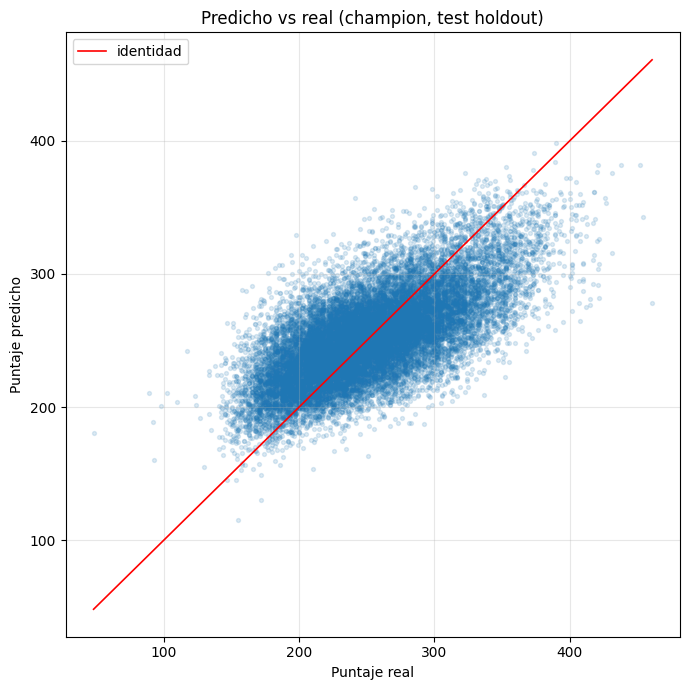

In [15]:
plot_predicted_vs_true(y_test_np, y_pred, save_path=FIGURES_DIR / 'pred_vs_true.png')

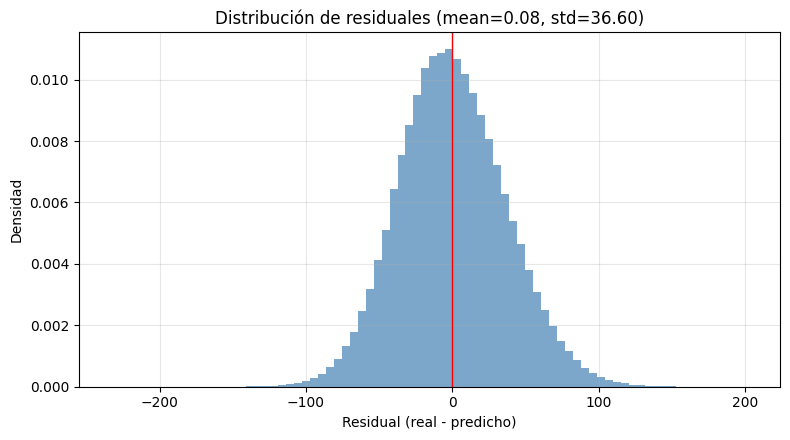

In [16]:
plot_residual_distribution(y_test_np, y_pred, save_path=FIGURES_DIR / 'residual_distribution.png')

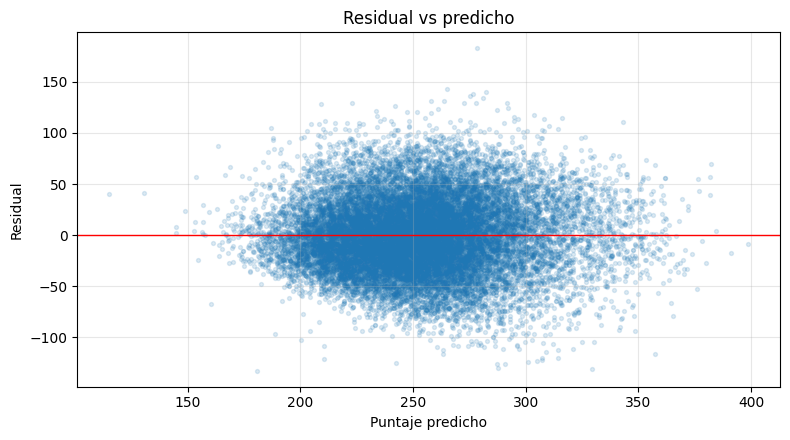

In [17]:
plot_residual_vs_pred(y_test_np, y_pred, save_path=FIGURES_DIR / 'residual_vs_pred.png')

In [18]:
calibration_by_bucket(y_test_np, y_pred, n_buckets=10)

,bucket,n,mean_true,mean_pred,bias,rmse
0,"(-0.001, 191.0]",69190,175.935318,217.422379,-41.487041,48.119190
1,"(191.0, 209.0]",69749,200.859070,230.343506,-29.484440,37.535126
2,"(209.0, 223.0]",66567,216.679947,237.414841,-20.734898,31.235167
3,"(223.0, 237.0]",71276,230.652039,243.612122,-12.960095,26.875374
4,"(237.0, 250.0]",67831,244.031815,249.360733,-5.328934,24.536665
5,"(250.0, 263.0]",64852,257.030609,254.492188,2.538433,24.156590
6,"(263.0, 278.0]",67968,270.981995,260.118835,10.863177,26.621689
7,"(278.0, 296.0]",66969,287.156860,267.215240,19.941628,32.136654
8,"(296.0, 321.0]",67609,307.919037,276.580933,31.338106,41.133244
9,"(321.0, 488.0]",67156,347.122742,298.142120,48.980614,57.846558


### Fairness por subgrupos

Reportamos RMSE/MAE/R² y bias (sesgo medio) por estrato, género, área (urbano/rural), naturaleza del colegio (oficial/privado) y departamento. Diferencias grandes en RMSE entre subgrupos indican que el modelo aprendió patrones desiguales.

In [11]:
fairness = fairness_report(y_test_np, y_pred, X_test_pd)

for col, df in fairness.items():
    print(f'\n--- {col} ---')
    display(df)


--- fami_estratovivienda ---


,group,n,rmse,mae,r2,mean_true,mean_pred,bias
0,Sin Estrato,10565,33.576263,26.345818,0.407675,212.777191,213.429550,-0.652360
1,Estrato 1,241978,34.389912,27.323191,0.333862,237.973007,237.862488,0.110530
2,NaN,21628,36.916546,29.062933,0.446754,228.794937,228.345551,0.449389
3,Estrato 2,228366,37.157608,29.742334,0.325377,255.301590,255.095413,0.206173
4,Estrato 6,7756,37.649632,29.636456,0.686397,309.869904,309.577484,0.292405
5,Estrato 3,125085,38.591770,30.888550,0.390119,269.972015,270.072968,-0.100966
6,Estrato 4,31592,39.860233,31.607155,0.544557,288.995453,289.285583,-0.290150
7,Estrato 5,12197,40.166039,31.600071,0.607284,300.145844,300.398010,-0.252166



--- estu_genero ---


,group,n,rmse,mae,r2,mean_true,mean_pred,bias
0,NaN,624,32.311550,25.379776,0.353747,240.331726,236.190033,4.141696
1,F,370039,35.116261,27.943850,0.473698,249.636093,249.605438,0.030660
2,M,308504,38.321934,30.573439,0.438348,257.764496,257.634430,0.130055



--- cole_area_ubicacion ---


,group,n,rmse,mae,r2,mean_true,mean_pred,bias
0,RURAL,101675,33.385525,26.408068,0.507598,235.953415,236.007767,-0.054348
1,URBANO,577491,37.142796,29.616274,0.438822,256.377380,256.274231,0.103155



--- cole_naturaleza ---


,group,n,rmse,mae,r2,mean_true,mean_pred,bias
0,OFICIAL,493164,35.651493,28.417192,0.366992,246.169052,246.086472,0.082578
1,NO OFICIAL,186003,39.019939,31.041666,0.530811,272.278992,272.207336,0.071653



--- estu_depto_reside ---


,group,n,rmse,mae,r2,mean_true,mean_pred,bias
0,VAUPES,468,27.899958,21.459299,0.478582,217.715805,217.646271,0.069553
1,CHOCO,5332,29.626659,23.023617,0.427059,211.452744,212.018082,-0.565338
2,VICHADA,601,30.327494,24.159065,0.424154,230.068222,231.032501,-0.964268
3,GUAINIA,349,30.531227,24.382940,0.580647,235.240692,232.964905,2.275777
4,AMAZONAS,1019,30.743217,23.959377,0.457465,221.078506,221.981140,-0.902627
5,GUAVIARE,1163,32.309177,25.783520,0.324575,231.143600,232.778137,-1.634550
6,LA GUAJIRA,9726,33.394928,26.294384,0.466536,226.677765,227.225937,-0.548151
7,CAUCA,17888,33.724823,26.530214,0.478313,237.065247,237.144226,-0.078988
8,CAQUETA,5097,33.793957,26.817080,0.400601,240.440063,240.974274,-0.534215
9,MAGDALENA,19129,34.040707,26.881933,0.383377,228.426102,228.522034,-0.095948


## 12. Interpretabilidad con SHAP

SHAP sobre una muestra de **train**, no de test (calcular SHAP sobre test para tomar decisiones de feature selection sería leakage). Buscamos:

- Que las top features coincidan con los hallazgos del EDA: estrato, educación de padres, capital tecnológico.

- Monotonicidad razonable en variables ordinales (a más estrato, más puntaje) en los dependence plots.

- Que ninguna feature derivada "trivialice" la señal (señal de que es un near-duplicate del target).

In [16]:
importance_df = full_pipeline_ml.explain(X_train_pd, sample_size=SHAP_SAMPLE_SIZE)
importance_df.head(25)

2026-05-24 17:19:48.726 | INFO     | src.modeling.pipeline:explain:391 - Using last version for execution...
2026-05-24 17:19:48.920 | INFO     | src.modeling.pipeline:explain:417 - Calculando SHAP values sobre 20,000 muestras...


,feature,mean_abs_shap
0,numeric__max_educacion_padres,7.043384
1,numeric__edad_estudiante_aprox,7.019018
2,binary__estu_genero,4.199500
3,numeric__pct_internet_mcpio,4.199007
4,nominal_low__cole_jornada_COMPLETA,3.959703
5,numeric__pct_oficial_mcpio,2.265868
6,numeric__capital_tecnologico,2.263306
7,ordinal__fami_educacionmadre,2.206805
8,nominal_low__cole_jornada_SABATINA,2.014950
9,numeric__pct_estrato_alto_mcpio,2.006351


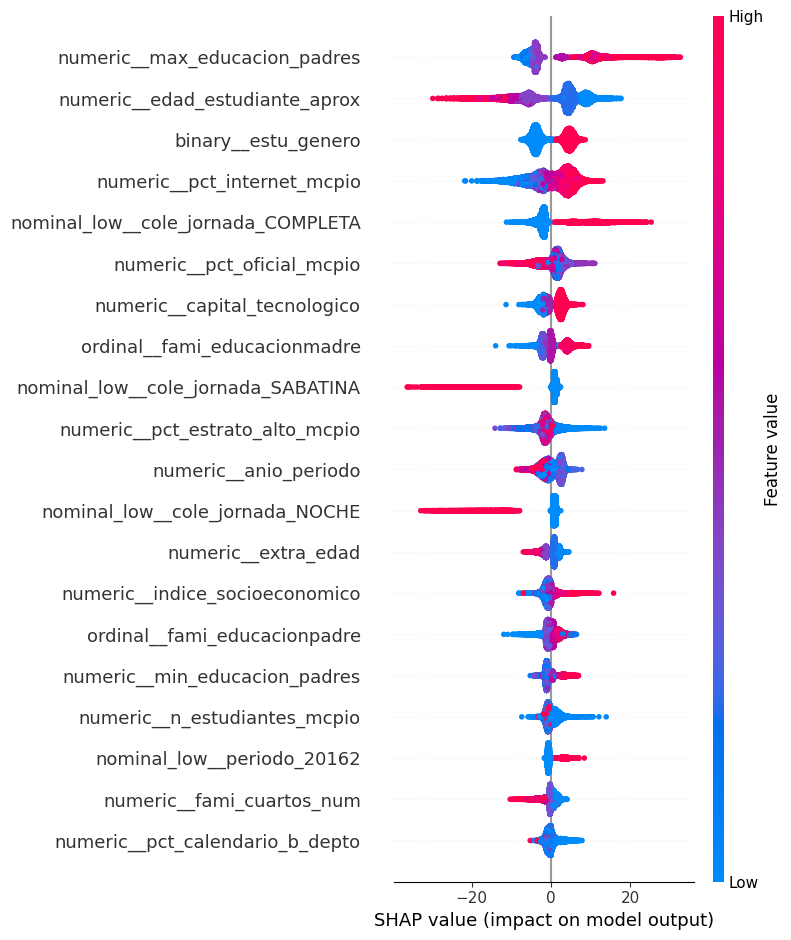

In [19]:
full_pipeline_ml.plot_shap_summary(save_path=FIGURES_DIR / 'shap_summary.png')

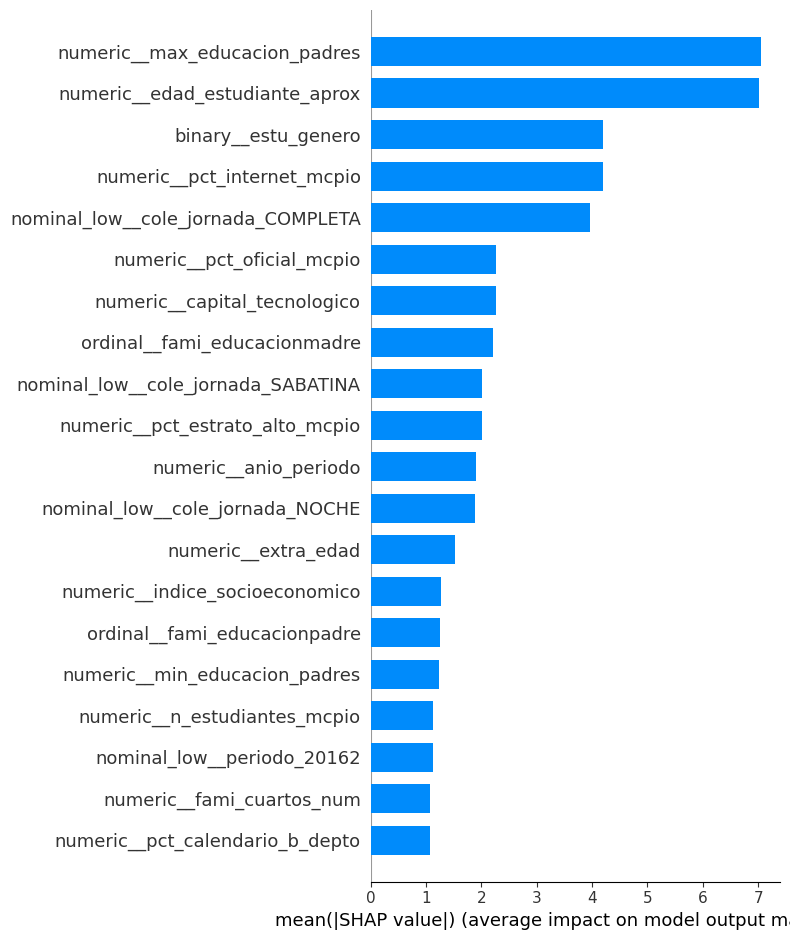

In [18]:
full_pipeline_ml.plot_shap_importance(save_path=FIGURES_DIR / 'shap_importance.png')

## 13. Persistencia del champion

Guardamos un bundle completo en `models/champion/`: pipeline serializado, metadata (versión de paquetes, semilla, hash del dataset), métricas de los tres esquemas, hiperparámetros, schema de features y model card. Esto es lo que la app de Streamlit va a cargar.

In [22]:
metrics_bundle = {
    'test_holdout': test_metrics,
    'group_kfold': group_cv,
    'temporal': temporal,
}

save_champion(
    pipeline=full_pipeline_ml.best_pipeline,
    out_dir=CHAMPION_DIR,
    model_name=CHAMPION,
    best_params=best_params,
    metrics=metrics_bundle,
    shap_importance=importance_df,
    X_train_sample=X_train_pd.head(1_000),
    target_col='punt_global',
    data_path=DATA_DIR / 'cleaned_dataset.parquet',
    seed=SEED,
    extra_metadata={
        'authors': ['Patricia Arango', 'Santiago Higuita', 'Alexander Pelaez'],
        'course': 'Aprendizaje de Máquina Aplicado',
        'institution': 'Universidad EAFIT',
    },
)

2026-05-24 17:27:12.895 | INFO     | src.modeling.champion:save_champion:147 - Pipeline guardado en ../models/champion/pipeline.joblib
2026-05-24 17:27:13.025 | INFO     | src.modeling.champion:save_champion:183 - Bundle del champion guardado en ../models/champion


PosixPath('../models/champion')

## 14. Conclusiones

### Resultados

El champion XGBoost alcanza **un RMSE 36.60, un MAE 29.14 y un R² 0.460** sobre 679k registros del test holdout. La diferencia con el RMSE de CV (36.71) es de 0.11 puntos: el modelo generaliza casi idéntico, sin overfitting al CV.

Frente al baseline de la entrega 1 (regresión lineal, árbol simple), la mejora es marginal. **Creemos que esto no es un fracaso del modelo, ya que es el techo del problema con la información disponible.** Para bajar significativamente el RMSE creemos que haría falta historia académica del estudiante, simulacros del Pre-Saber, hábitos de estudio o datos de asistencia, entre otros datos, que no están en el dataset público del ICFES.

### Robustez

| Esquema | RMSE | Lectura |
|---|---|---|
| Test holdout (random, stratified periodo) | 36.60 | Pregunta de negocio principal |
| GroupKFold por municipio (5 folds) | 40.06 | Generalización a municipios no vistos |
| Split temporal (train ≤ 2019-4) | 40.41 | Generalización a cohortes futuras |

El modelo se degrada ~10% al evaluarlo sobre distribuciones distintas a la de entrenamiento. Dentro de su distribución generaliza bien (CV 36.71 ≈ holdout 36.60, sin overfitting).

### Diagnóstico de residuales

- **Predicho vs real:** la nube sigue la línea de identidad, centrada y simétrica. Se observa regresión a la media en las colas (puntajes muy bajos sobreestimados, muy altos subestimados), comportamiento esperado con R² < 1.

- **Distribución de residuales:** gaussiana, centrada en 0 (mean = 0.08), std = 36.60. No se ve sesgo sistemático, y se evidencian colas extendidas hasta ±200 con densidad baja.

- **Residual vs predicho:** hay dispersión homogénea en todo el rango de predicción (150-400). No hay heterocedasticidad ni patrones visibles. El modelo está bien calibrado.

### Fairness

Desagregamos el desempeño por estrato, género, área urbano/rural, naturaleza del colegio y departamento. El **bias** (real − predicho promedio) es bajo en todos los grupos (rango -2.3 a +4.1), lo que indica que el modelo no sub-predice ni sobre-predice sistemáticamente a ningún subgrupo. La **precisión (RMSE)** sí varía:

- **Estrato:** RMSE crece con el estrato (33.6 en Sin Estrato → 40.2 en Estrato 5). Pero no es sesgo, sino que es heterogeneidad, pues la dispersión real de puntajes es mayor en estratos altos.

- **Género:** F tiene RMSE 35.1 vs M 38.3. El modelo predice ligeramente mejor a mujeres.

- **Área:** RURAL tiene RMSE 33.4 (R² 0.51) vs URBANO 37.1 (R² 0.44). Esto es contra-intuitivo, pues la zona rural es más predecible porque la varianza interna es menor.

- **Naturaleza:** OFICIAL RMSE 35.7 (R² 0.37) vs NO OFICIAL 39.0 (R² 0.53). El modelo capta más varianza en colegios privados (R² alto) pero con mayor error absoluto, porque los puntajes en colegios privados son más dispersos.

- **Departamento:** rango de 27.9 (Vaupés) a 39.9 (San Andrés). Departamentos pequeños predicen mejor por menor varianza; los grandes (Bogotá, Antioquia, Valle) están en RMSE 37-39, dentro del rango global.

**Lectura clave:** el modelo no discrimina (bias bajo en todos los grupos), pero su precisión depende del subgrupo. Predicciones individuales en zonas o subgrupos donde la dispersión es mayor (estratos altos, urbano, privados) deben tomarse con un intervalo de confianza más amplio.


### Interpretabilidad

El SHAP confirma señal fuerte y direccionalmente coherente con el dominio evaluado:

- **Educación máxima de los padres** es la feature más importante (|SHAP| ≈ 7). Valores altos empujan el puntaje hasta +30; valores bajos lo restan en magnitud similar.

- **Edad del estudiante**: relación inversa. Estudiantes mayores predicen peor desempeño. El modelo captura extra-edad y trayectoria educativa interrumpida como una señal negativa.

- **Género**: el beeswarm muestra dos clusters bien separados; el modelo discrimina consistentemente entre F y M.

- **% internet en el municipio**: alto → positivo. Captura desarrollo y conectividad regional.

- **Jornada del colegio**: la jornada completa aporta hasta +25 puntos, mientras que sabatina y nocturna restan hasta -30. Lo cual puede tener sentido, ya que la jornada completa es típica de colegios con más horas efectivas de clase, mientras que las nocturnas y sabatinas suelen atender estudiantes que trabajan o retoman estudios interrumpidos, con menos tiempo y condiciones para prepararse.

- **% colegios oficiales en el municipio**: relación negativa, coherente con la brecha oficial vs privado del EDA.

- **Estrato e índice socioeconómico** aparecen abajo en el ranking. El modelo encuentra mejor señal en variables más finas (educación de padres, capital tecnológico, % internet) que en el estrato directo.

El modelo además de capturar el nivel socioeconómico, combina contexto familiar, condiciones del entorno y trayectoria educativa (cursó de forma regular el colegio). Esto es coherente con la literatura sobre desigualdades educativas en Colombia.

### Limitaciones

- **Sesgo de selección:** solo estudiantes que presentaron Saber 11.

- **Concept drift:** datos hasta 2022. La pandemia y posibles cambios en el ICFES degradan el modelo en cohortes futuras (RMSE temporal +10%).

- **Variables auto-reportadas:** estrato, internet y educación de padres pueden tener sesgo de respuesta.

- **Techo del problema:** R² ≈ 0.5 es el límite con las features disponibles.

### Uso ético

El modelo es una herramienta analítica académica. El uso legítimo es educativo e investigativo.